### Preamble

We load the required libraries and packages below.

This notebook refers to the Kaggle competition at https://www.kaggle.com/competitions/playground-series-s5e3.
The goal is to predict rainfall for each day of the year.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import lightgbm as lgb
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, roc_auc_score, log_loss, confusion_matrix, accuracy_score

### Load data and inspect

In [2]:
# load the train data and check
train_csv = pd.read_csv('train.csv')

# check the dataframe
train_csv.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [3]:
# check the train dataframe for any missing values
train_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2190 non-null   int64  
 1   day            2190 non-null   int64  
 2   pressure       2190 non-null   float64
 3   maxtemp        2190 non-null   float64
 4   temparature    2190 non-null   float64
 5   mintemp        2190 non-null   float64
 6   dewpoint       2190 non-null   float64
 7   humidity       2190 non-null   float64
 8   cloud          2190 non-null   float64
 9   sunshine       2190 non-null   float64
 10  winddirection  2190 non-null   float64
 11  windspeed      2190 non-null   float64
 12  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 222.6 KB


We see that there are no missing values in the training dataset which makes allows us to use the data directly.

In [4]:
df = train_csv.drop(columns=['id'])
df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [5]:
# Sometimes the names of columns contain spaces that are not visible easily. 
# Also here the temperature column is misspelled, but I'll leave that as is
df.columns

Index(['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'sunshine', 'winddirection', 'windspeed',
       'rainfall'],
      dtype='object')

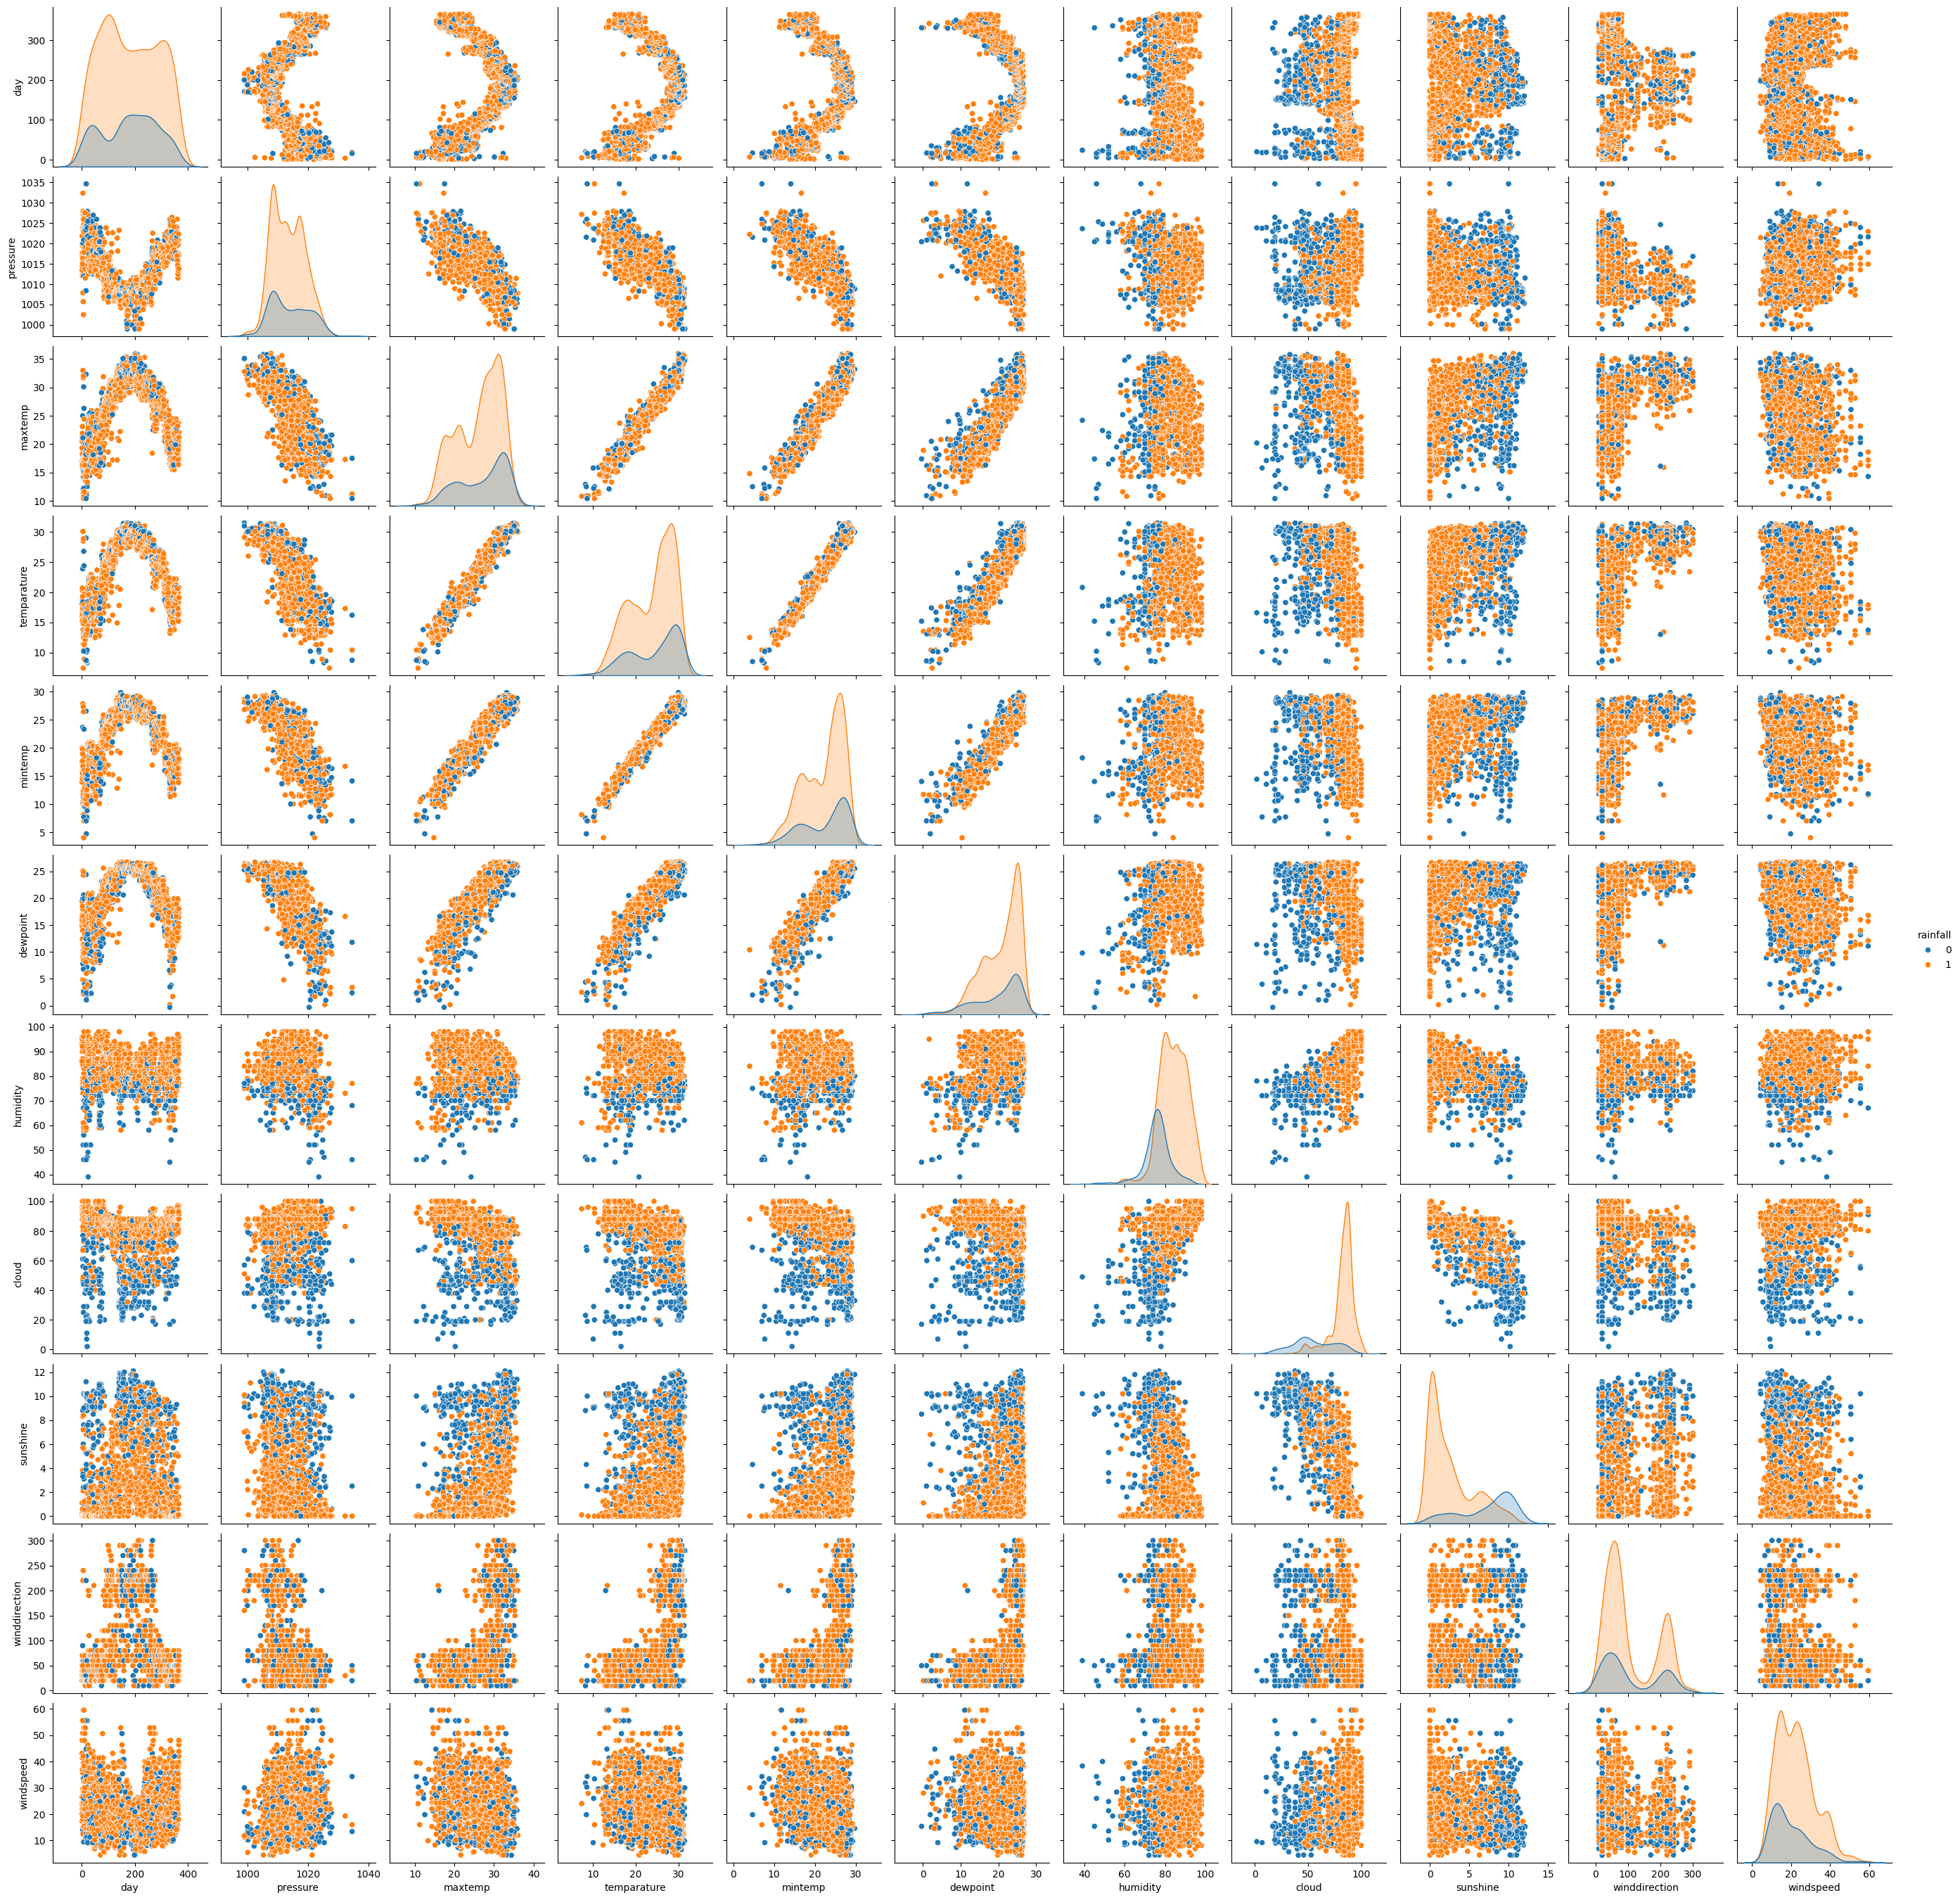

In [6]:
sns.pairplot(df,hue='rainfall')
plt.show()

Pairplot allows to better inspect the data - specially if the data is well separated in any features

In [7]:
# is the data balanced?
df['rainfall'].value_counts()

rainfall
1    1650
0     540
Name: count, dtype: int64

Dataset is imbalanced. This might need addressing, but we won't try to fix this here since this might be reflective of the real world data.

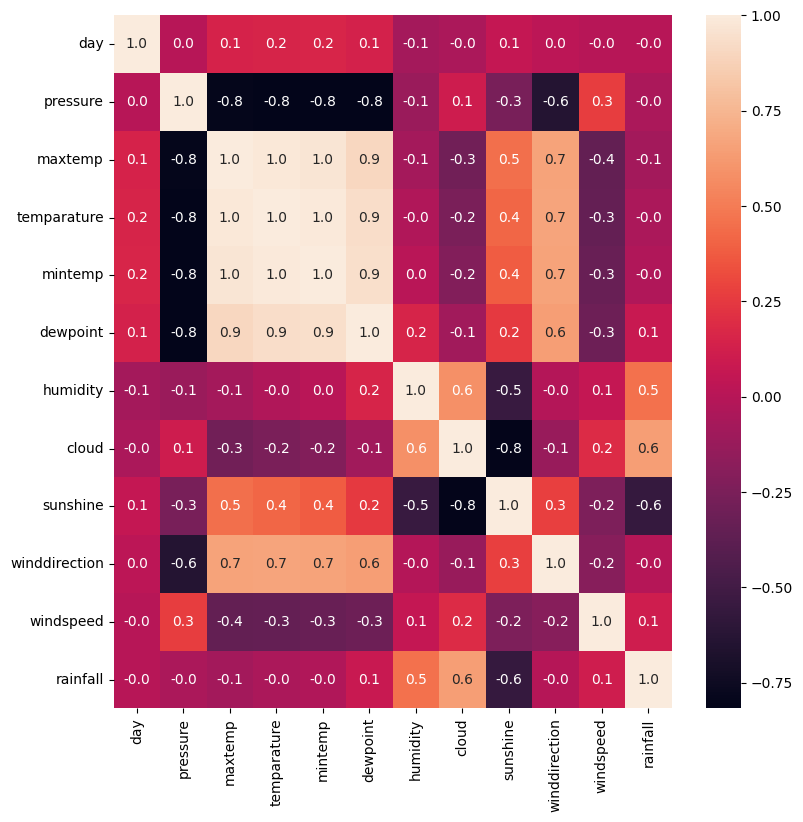

In [8]:
plt.figure(figsize=(9,9))
sns.heatmap(df.corr(),annot=True,fmt=".1f")
plt.show()

Some data appear to be highly correlated with each other.

## No Hyperparameter Optimization

### ML parts

In [9]:
# separate truth data from the training data
X = df.drop(columns=['rainfall'])
y = df.pop('rainfall')

In [10]:
X.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2
1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9
2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1
3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6
4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8


In [11]:
y.head()

0    1
1    1
2    1
3    1
4    0
Name: rainfall, dtype: int64

In [12]:
# Split into train, validation, and test sets
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Train size: {len(X_train)}, Validation size: {len(X_val)}, Test size: {len(X_test)}")

Train size: 1314, Validation size: 438, Test size: 438


The split was done in this manner so that I can check the training and validation losses later.

### Train the classifier

In [13]:
params= {'colsample_bytree': np.float64(0.9213923721539394), 
                  'learning_rate': np.float64(0.09461037177139194), 
                  'max_depth': 4, 
                  'min_child_samples': 77, 
                  'n_estimators': 457, 
                  'num_leaves': 118, 
                  'reg_alpha': np.float64(0.4126176769114265), 
                  'reg_lambda': np.float64(0.37201808579278317), 
                  'subsample': np.float64(0.9105651842967988)}

# create model
model = lgb.LGBMClassifier(**params)

The parameters above are not optimized for this problem, I naively took them from some other problem (not good).

In [14]:
%%time
# Fit with validation set for early stopping
# Note: We don't use the test set during training!
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['train', 'valid'],
    eval_metric=['logloss', 'auc'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=10)
    ]
)

[LightGBM] [Info] Number of positive: 986, number of negative: 328
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1450
[LightGBM] [Info] Number of data points in the train set: 1314, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.750381 -> initscore=1.100643
[LightGBM] [Info] Start training from score 1.100643
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

LGBMClassifier(colsample_bytree=np.float64(0.9213923721539394),
               learning_rate=np.float64(0.09461037177139194), max_depth=4,
               min_child_samples=77, n_estimators=457, num_leaves=118,
               reg_alpha=np.float64(0.4126176769114265),
               reg_lambda=np.float64(0.37201808579278317),
               subsample=np.float64(0.9105651842967988))

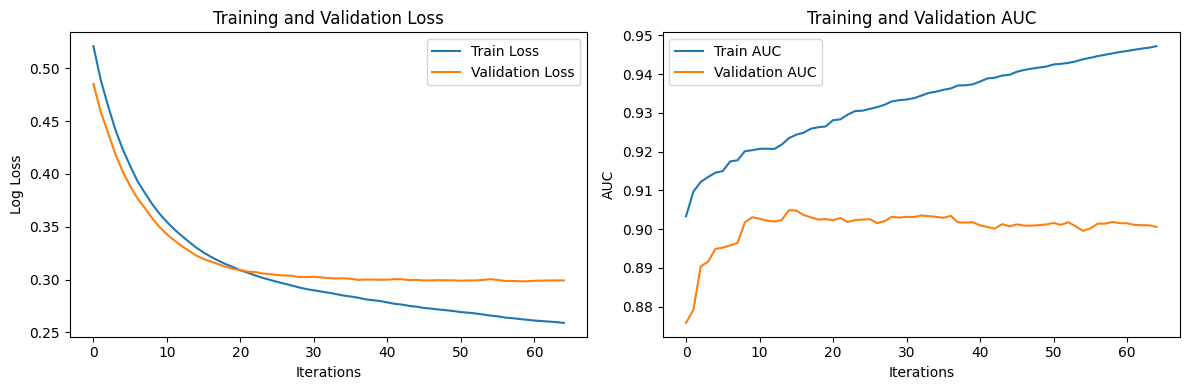

In [15]:
# Plot training and validation curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(model.evals_result_['train']['binary_logloss'], label='Train Loss')
plt.plot(model.evals_result_['valid']['binary_logloss'], label='Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Log Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(model.evals_result_['train']['auc'], label='Train AUC')
plt.plot(model.evals_result_['valid']['auc'], label='Validation AUC')
plt.xlabel('Iterations')
plt.ylabel('AUC')
plt.legend()
plt.title('Training and Validation AUC')

plt.tight_layout()
plt.show()

### Test metrics

In [16]:
# need probabilities, not predictions
predictions = model.predict(X_test)

# probabilities
probabilities = model.predict_proba(X_test)[:, 1]

# Test performances
print(f'Accuracy: {accuracy_score(y_test, predictions):.4f}')
print(f'AUC: {roc_auc_score(y_test, probabilities):.4f}')

Accuracy: 0.8630
AUC: 0.8627


In [17]:
# Confusion matrix
cm_lgb = confusion_matrix(y_test, predictions)

# summary
print("Confusion matrix:\n", cm_lgb)

Confusion matrix:
 [[ 73  46]
 [ 14 305]]


Confusion matrix shows the model's classification performance. Depending on the problem, the 46 false positives, and 14 false negatives might be really bad or not as bad.

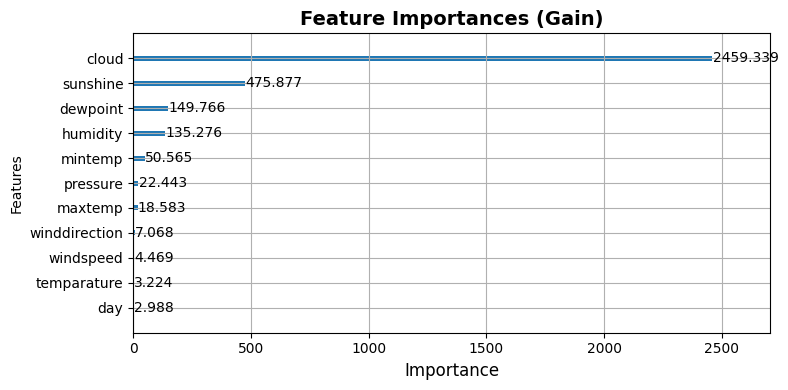

In [18]:
# Plot using LightGBM's function
fig, ax = plt.subplots(figsize=(8, 4))
lgb.plot_importance(model, importance_type='gain', ax=ax, max_num_features=20)
plt.title('Feature Importances (Gain)', fontsize=14, fontweight='bold')
plt.xlabel('Importance', fontsize=12)
plt.tight_layout()
# plt.savefig('feature_importance_gain.png', dpi=150, bbox_inches='tight')
plt.show()

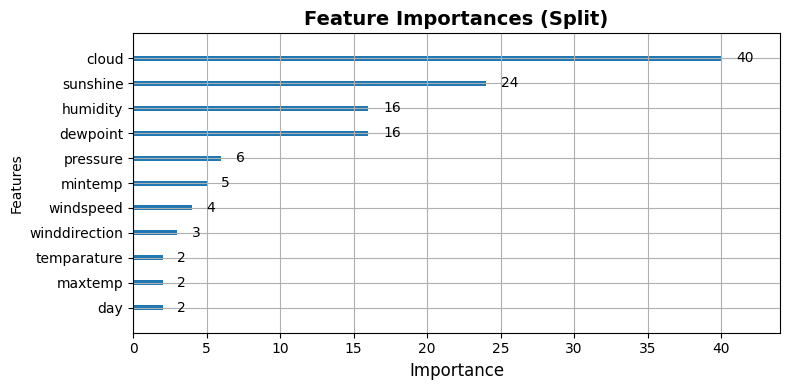

In [19]:
# Plot using LightGBM's function
fig, ax = plt.subplots(figsize=(8, 4))
lgb.plot_importance(model, importance_type='split', ax=ax, max_num_features=20)
plt.title('Feature Importances (Split)', fontsize=14, fontweight='bold')
plt.xlabel('Importance', fontsize=12)
plt.tight_layout()
# plt.savefig('feature_importance_split.png', dpi=150, bbox_inches='tight')
plt.show()

We see not all features are equally important. I will probably use the top 3 or 4 in an attempt to improve the accuracy and exclude the rest.

### Make predictions on the test data

In [20]:
test_df = pd.read_csv('test.csv')
id_df = test_df.pop('id')
test_df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
1,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9
3,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6
4,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4


In [21]:
# the probabilities have to be submitted
test_proba = model.predict_proba(test_df)

In [22]:
# convert predictions to pandas df
sub_df = pd.DataFrame({
    'id': id_df,
    'rainfall': test_proba[:,1]
})

# save for subimssion
# Save the DataFrame to a CSV file, including the index
sub_df.to_csv('submission_LGBM_1.csv', index=False)

In [23]:
sub_df.head()

,id,rainfall
0,2190,0.926693
1,2191,0.926693
2,2192,0.867134
3,2193,0.265619
4,2194,0.231991


This submission got a private score of $0.89865$ for the rainfall Kaggle competition. Not bad for doing no hyperparameter optimization as well as using all the features which might be hurting the model.

## Hyperparameter optimization

#### For a simple implementation of hyperparameter optimization, I use `RandomizedSearchCV`

In [24]:
%%time
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Initialize LightGBM Classifier
lgbm_clf = lgb.LGBMClassifier(random_state=42)

# Define the parameter distributions
param_dist = {
    'num_leaves': randint(20, 80),
    'learning_rate': uniform(0.01, 0.2),
    'n_estimators': randint(100, 500),
    'min_child_weight': uniform(0.001, 0.01),
    'min_child_samples': randint(50, 150),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1),
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=lgbm_clf,
    param_distributions=param_dist,
    n_iter=50,           # Number of parameter settings sampled
    scoring='neg_mean_squared_error', 
    cv=3,                # 3-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit the search
random_search.fit(X_train, y_train)

# Get the best model
best_model = random_search.best_estimator_
print(f"Best parameters: {random_search.best_params_}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[LightGBM] [Info] Number of positive: 986, number of negative: 328
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000333 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1450
[LightGBM] [Info] Number of data points in the train set: 1314, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.750381 -> initscore=1.100643
[LightGBM] [Info] Start training from score 1.100643
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

#### Train the classifier again

In [25]:
# extract the best parameters
params = random_search.best_params_

# create model
model = lgb.LGBMClassifier(**params)

In [26]:
%%time
# Fit with validation set for early stopping
# Note: We don't use the test set during training!
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['train', 'valid'],
    eval_metric=['logloss', 'auc'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=10)
    ]
)

[LightGBM] [Info] Number of positive: 986, number of negative: 328


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000752 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1450
[LightGBM] [Info] Number of data points in the train set: 1314, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.750381 -> initscore=1.100643
[LightGBM] [Info] Start training from score 1.100643
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

LGBMClassifier(learning_rate=np.float64(0.010104075399063163),
               min_child_samples=126,
               min_child_weight=np.float64(0.009607305832563435),
               n_estimators=458, num_leaves=25,
               reg_alpha=np.float64(0.5107473025775657),
               reg_lambda=np.float64(0.417411003148779))

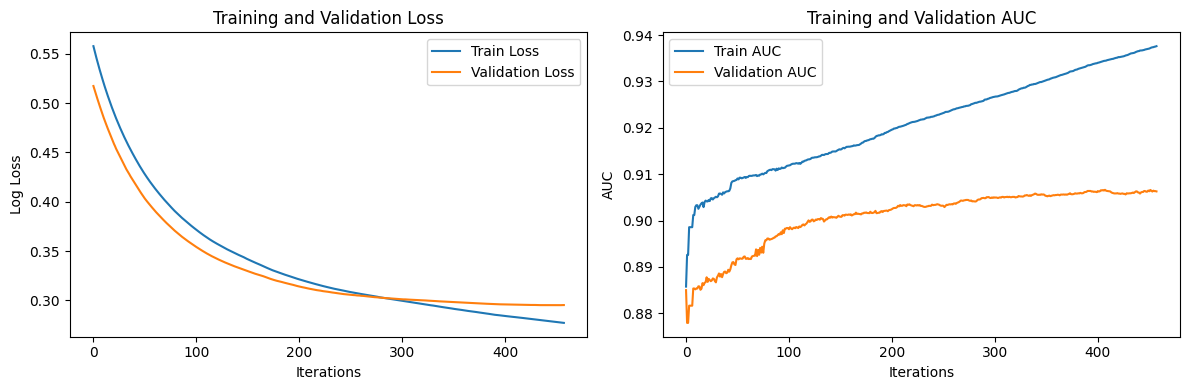

In [27]:
# Plot training and validation curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(model.evals_result_['train']['binary_logloss'], label='Train Loss')
plt.plot(model.evals_result_['valid']['binary_logloss'], label='Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Log Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(model.evals_result_['train']['auc'], label='Train AUC')
plt.plot(model.evals_result_['valid']['auc'], label='Validation AUC')
plt.xlabel('Iterations')
plt.ylabel('AUC')
plt.legend()
plt.title('Training and Validation AUC')

plt.tight_layout()
plt.show()

#### Test metrics

In [28]:
# need probabilities, not predictions
predictions = model.predict(X_test)

# probabilities
probabilities = model.predict_proba(X_test)[:, 1]

# Test performances
print(f'Accuracy: {accuracy_score(y_test, predictions):.4f}')
print(f'AUC: {roc_auc_score(y_test, probabilities):.4f}')

Accuracy: 0.8562
AUC: 0.8633


In [29]:
# Confusion matrix
cm_lgb = confusion_matrix(y_test, predictions)

# summary
print("Confusion matrix:\n", cm_lgb)

Confusion matrix:
 [[ 75  44]
 [ 19 300]]


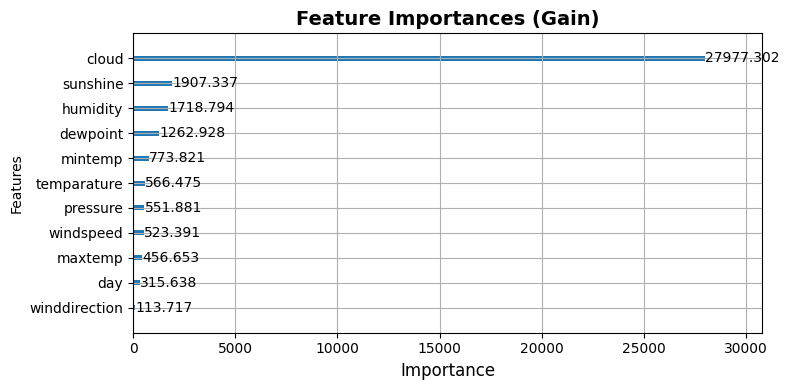

In [30]:
# Plot using LightGBM's function
fig, ax = plt.subplots(figsize=(8, 4))
lgb.plot_importance(model, importance_type='gain', ax=ax, max_num_features=20)
plt.title('Feature Importances (Gain)', fontsize=14, fontweight='bold')
plt.xlabel('Importance', fontsize=12)
plt.tight_layout()
# plt.savefig('feature_importance_gain.png', dpi=150, bbox_inches='tight')
plt.show()

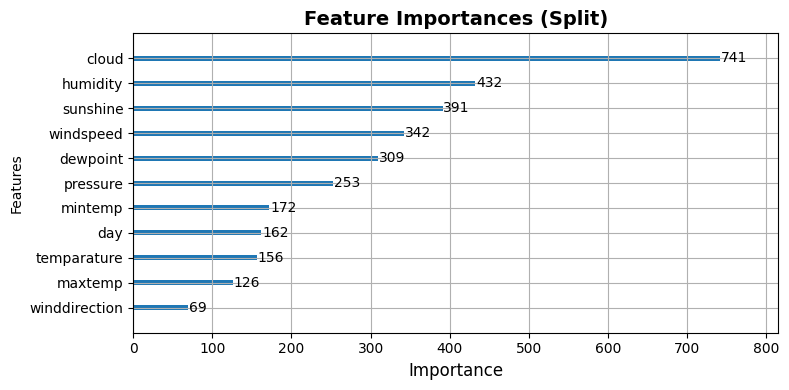

In [31]:
# Plot using LightGBM's function
fig, ax = plt.subplots(figsize=(8, 4))
lgb.plot_importance(model, importance_type='split', ax=ax, max_num_features=20)
plt.title('Feature Importances (Split)', fontsize=14, fontweight='bold')
plt.xlabel('Importance', fontsize=12)
plt.tight_layout()
# plt.savefig('feature_importance_split.png', dpi=150, bbox_inches='tight')
plt.show()

#### Make predictions on the test data

In [32]:
test_df = pd.read_csv('test.csv')
id_df = test_df.pop('id')
test_df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
1,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9
3,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6
4,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4


In [33]:
# the probabilities have to be submitted
test_proba = model.predict_proba(test_df)

In [34]:
# convert predictions to pandas df
sub_df = pd.DataFrame({
    'id': id_df,
    'rainfall': test_proba[:,1]
})

# save for subimssion
# Save the DataFrame to a CSV file, including the index
sub_df.to_csv('submission_LGBM_6.csv', index=False)

In [35]:
sub_df.head()

,id,rainfall
0,2190,0.983252
1,2191,0.975349
2,2192,0.949362
3,2193,0.153427
4,2194,0.097255


This submission scored $0.89807$, lower than the submission above which is surprising!